# Week 2 — Describing Data



## Lecture recording

:::{seealso} Please refer to the lecture recording on Canvas
:::


Data is one of the most valuable resources in the world today - so much so that it's often called "the new oil." Just look at the [biggest companies in the world](https://stockanalysis.com/list/biggest-companies/): many of them are tech companies, built on social media, or on the hardware and software behind social media and AI. And what drives both? *Data*.

But raw data, like crude oil, isn't much use on its own - it first has to be refined. To explore data, clean it up, and turn it into something useful, we turn to the field of *statistics*.

## Two flavours of statistics : Descriptive Vs Inferential

Statistics can be split into two broad camps.

📊The first is **descriptive statistics**. This is exactly what it sounds like - ways of *describing* and *summarising* data. If someone asks "how tall are students in this class, on average?" or "how spread out are those heights?", you're in descriptive statistics territory. You're not trying to draw any big conclusions - just getting a clear picture of what's in front of you.

📈 The second is **inferential statistics**. Here, you go one step further: you take a *sample* of data and use it to draw conclusions about a much larger group. For example, if you measure the properties of 200 alloy samples and use that to predict how alloys in general will behave - that's inference. You're essentially making an educated guess, backed by maths.

In this course, we'll spend time with both - but we'll start with descriptive statistics, because you can't make good inferences about data you don't yet understand.

| Descriptive Statistics | Inferential Statistics|
|---|---|
| Mean / Median / Mode | Hypothesis testing / p-values|
| Variance & Standard deviation | Confidence intervals |
| Skewness & kurtosis | Regression analysis |
| Correlation |   |

**Central limit theorem** creates a bridge between descriptive and inferential statistics.

Machine learning builds up on these fundamentals, so once you gain an understanding of these statistical methods we can move into Machine learning ideas. 

# Descritpive Statistics

**Mean (Average)**

$\bar{x}=\frac{\text{𝑆𝑢𝑚 𝑜𝑓 𝑎𝑙𝑙 𝑑𝑎𝑡𝑎}}{\text{𝑁𝑜. 𝑜𝑓 𝑑𝑎𝑡𝑎𝑝𝑜𝑖𝑛𝑡𝑠}}$

**Median** - The middle number; found by ordering all data points and picking out the one in the middle (or if there are two middle numbers, taking the mean of those two numbers).

<img src="images/lec02_median.png" width="400">

**Mode** - The most frequent number - that is, the number that occurs the highest number of times.

**Variance**
is an indication of how spread out the data is from the mean, therefore it calculates the average of the squared differences from the mean.
Should be noted that there's a population variance and a sample variance, and most often when we talk about variance, we are referring to the sample variance, since we don't/ can't measure the whole population. But note that there are exeptions such as in a sensus.

$\text{Population Variance} =\sigma^2= \Sigma_{i=1}^n\frac{(x_i-\bar{x})^2}{n}$

$\text{Sample Variance} = S^2 =\Sigma_{i=1}^n\frac{(x_i-\bar{x})^2}{n-1}$

where $n$ is the number of items in the sample, $x_i$ is the value of any given data point & $\bar{x}$ is the mean

**Standard Deviation** 
This is simply the square root of Variance.

$SD = \sqrt{Var}=\sigma$

## Try it yourself 💪

Here is a tiny materials dataset: the experimental **band gaps** (in eV) of ten
semiconductors and insulators. Notice that **SiO₂** sits far above the rest - keep
an eye on it.

Run the cell below to compute the summary numbers and draw a histogram. Try
changing the data and running it again.

Mean    = 2.85 eV
Median  = 1.88 eV
Std dev = 2.63 eV


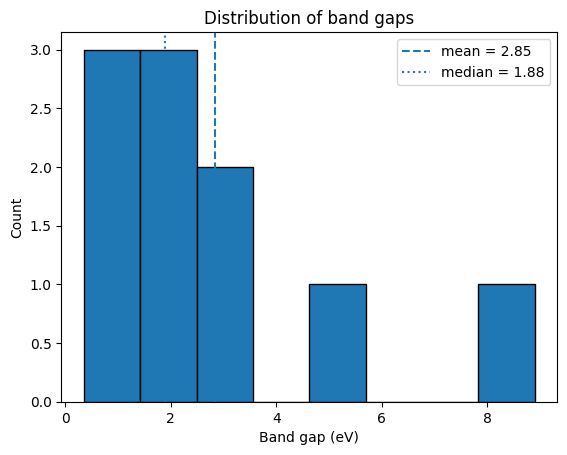

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A small materials dataset: experimental band gaps (eV).
# Later you can load your own file instead:  df = pd.read_csv("data/your_data.csv")
data = {
    "material": ["Ge", "InAs", "Si", "GaAs", "CdTe", "GaP", "ZnO", "GaN", "Diamond", "SiO2"],
    "band_gap_eV": [0.67, 0.35, 1.12, 1.42, 1.50, 2.26, 3.37, 3.40, 5.47, 8.90],
}
df = pd.DataFrame(data)

mean_bg = df["band_gap_eV"].mean()
median_bg = df["band_gap_eV"].median()
std_bg = df["band_gap_eV"].std()

print(f"Mean    = {mean_bg:.2f} eV")
print(f"Median  = {median_bg:.2f} eV")
print(f"Std dev = {std_bg:.2f} eV")

plt.figure()
plt.hist(df["band_gap_eV"], bins=8, edgecolor="black")
plt.axvline(mean_bg, linestyle="--", label=f"mean = {mean_bg:.2f}")
plt.axvline(median_bg, linestyle=":", label=f"median = {median_bg:.2f}")
plt.xlabel("Band gap (eV)")
plt.ylabel("Count")
plt.title("Distribution of band gaps")
plt.legend()
plt.show()

## What just happened? 🤷

Look at how far apart the **mean** and **median** lines are. That single high value
(SiO₂) pulled the *mean* upward, while the *median* hardly moved.

:::{seealso} Carry this idea forward
In **Week 4** we deal with outliers directly during data cleaning - and in
materials science the outlier is often the *interesting* result, not noise to throw
away. Remember this band-gap example when we get there.
:::


## Central Limit Theorem (CLT) 💡

When you take a sufficiently large number of random samples from any population, the distribution of those sample means will approximate a normal distribution, regardless of the population's original distribution.

<img src="images/lec02_clt.png" width="600">

To see how this works refer to the worked examples on the central limit theorem in the following pages.


## What is a probability distribution?

The Central Limit Theorem we just met involved a phrase we glossed over a little: the *distribution* of sample means *approaches a normal distribution*. It's time to pin down what a "distribution" actually is, because the idea runs through almost everything that follows.

A **probability distribution** is just a description of:

> *what values a random quantity can take, and how likely each value is.*

Think of it as the **shape of all possible outcomes**. If you measured the same quantity over and over again - grain diameters in a polished sample, failure times of a batch of specimens, the score of a coin-flipping experiment - the histogram you'd build up after many repeats traces out the *probability distribution* of that quantity.

The histogram is the empirical, finite-sample version. The probability distribution is the **idealised, infinite-sample limit** - a property of the *population* rather than of any one sample we drew from it.

---

## Discrete vs continuous

There are two flavours, depending on what kind of values the quantity can take:

- **Discrete distributions** describe things you **count**: number of defects on a wafer, number of heads in 10 coin flips, number of grains intersected by a line. The variable can only take separated integer values.
- **Continuous distributions** describe things you **measure**: tensile strength, time to failure, particle diameter, temperature. The variable can take *any* value in a range, including fractions.

Visually, discrete distributions are shown as **bar charts** (probability sits on each integer), while continuous distributions are shown as **smooth curves** (probability sits *under* the curve over a range of values).

---

## A small gallery of common distributions

You'll meet the same handful of distributions over and over in materials science and machine learning. Here is what their shapes look like:

<img src="images/lec02_distributions.png" width="700">

Six distributions you will encounter repeatedly. Top row: three **continuous** distributions (smooth curves). Bottom row: a fourth continuous one (log-normal), then two **discrete** ones (bars on integer values).


A one-line tour of each:

- **Normal (Gaussian)** - the symmetric bell curve. Used to model many natural measurements that arise from many small additive effects: measurement noise, errors, deviations around a mean.
- **Uniform** - every value in a range is equally likely. Used to model "no preference" situations, random sampling positions, or pseudo-random number generators.
- **Exponential** - peaked at zero, with a long right tail. Used to model **waiting times** between random events: time until the next click of a Geiger counter, time until a component fails (assuming a constant failure rate).
- **Log-normal** - looks like a "squeezed" bell with a long right tail. Used when the *logarithm* of the quantity is normally distributed. Common in nature for things that result from many small **multiplicative** effects: particle sizes, grain sizes, mineral concentrations.
- **Binomial** - the number of "successes" in a fixed number of independent yes/no trials. Used for counting defects per batch (each item passes or fails) or counting how many specimens in a group meet a spec.
- **Poisson** - the number of independent events occurring in a fixed interval of time or space. Used for rare-event counts: number of dust particles in a cleanroom field-of-view, number of cosmic-ray hits on a sensor per second.

A few others that come up often in materials science and engineering but aren't shown above:

- **Weibull** - extremely common for the **strength of brittle materials** (ceramics, fibres, composites) and for time-to-failure data with non-constant failure rates. Its shape is flexible - by tuning two parameters it can look like an exponential, a bell, or many things in between.
- **Bernoulli** - a single yes/no trial. The simplest building block. A binomial is just $n$ independent Bernoullis added together.

---

The probability density function of a normal distribution with mean $\mu$ and standard deviation $\sigma$ is:

$$
f(x) \;=\; \frac{1}{\sigma\sqrt{2\pi}} \, \exp\!\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)
$$

Two pieces are worth naming separately:

- **$\dfrac{1}{\sigma\sqrt{2\pi}}$** - a normalising constant. It is whatever number is needed to make the total area under the curve equal to 1 (every probability distribution has to integrate to 1). It does not affect the *shape*; it just sets the vertical scale.
- **$\exp\!\left(-\dfrac{(x - \mu)^2}{2\sigma^2}\right)$** - the part that gives the bell its shape. The numerator $(x - \mu)^2$ is the **squared distance of $x$ from the mean**, so values close to $\mu$ are barely penalised and values far from $\mu$ are heavily penalised. The denominator $2\sigma^2$ controls how *quickly* that penalty grows: a small $\sigma$ makes the bell narrow and sharply peaked, a large $\sigma$ makes it broad and flat.

```{admonition} Why this expression shows up everywhere
:class: tip
Keep an eye on the term $(x - \mu)^2$. This **squared deviation from the mean** is the same quantity we summed up when computing variance - and it is the same quantity that reappears later in this course as the **mean squared error** of a model's predictions, and as the loss function minimised by **least-squares regression**. The link is not a coincidence: least squares is equivalent to assuming the noise in your data is normally distributed. We will return to this connection when we get to regression.
```

## 👀Why does the normal distribution get all the attention? 👀

If you read any textbook on statistics or machine learning, you'll notice the **normal distribution** is mentioned far more often than the others. There are three good reasons for this.

**(1) The Central Limit Theorem.** This is the big one. The CLT tells us that *sums and averages* of many independent quantities tend toward a normal distribution - *no matter what the underlying distribution looked like*. Since a great many of the numbers we calculate in practice are sums or averages (sample means, total errors, aggregated effects), the normal distribution shows up as the *output* of all sorts of processes, even when the inputs were nothing like normal.

**(2) Many real measurements are roughly normal.** Whenever a measurement is the result of many small, independent perturbations adding up - measurement error from many small sources, deviations around a target value caused by many small process variations - the result tends to be approximately bell-shaped. This is essentially the CLT acting in the physical world, not just in our statistics.

**(3) It's mathematically very friendly.** The normal distribution has clean formulas, nice properties (the sum of two normals is normal; the mean and variance fully describe it), and underlies most "classical" statistical methods - confidence intervals, t-tests, linear regression, principal component analysis. A lot of machinery has been built assuming normality, and it works well when that assumption is reasonable.

A useful consequence of the normal's symmetry and known shape is the **68–95–99.7 rule**:

```{admonition} The 68–95–99.7 rule
:class: tip
For a normal distribution with mean $\mu$ and standard deviation $\sigma$:

- about **68%** of values lie within $\mu \pm \sigma$ (one standard deviation),
- about **95%** within $\mu \pm 2\sigma$,
- about **99.7%** within $\mu \pm 3\sigma$.

So if a measurement is more than $3\sigma$ away from the mean, it is unusual - there is only about a 0.3% chance under a normal distribution. This rule is the quick mental check behind a lot of everyday "is this an outlier?" reasoning.
```

---

## ...but don't assume everything is normal

A word of caution: the normal distribution is so embedded in statistics that it is tempting to assume *all* data is approximately normal. **A great deal of materials data is not.**

- **Particle sizes and grain sizes** are usually **log-normal** - peaked at small values with a long right tail. Computing a plain mean and standard deviation as if they were normal can be misleading.
- **Strengths of brittle ceramics** are usually **Weibull-distributed** - there is a "weakest link" effect from internal flaws, which the normal distribution simply does not capture.
- **Failure times** are often **exponential or Weibull**, not normal.
- **Counts of defects** are typically **Poisson**, not normal.

Before computing summary statistics or fitting a model, it is always worth **plotting a histogram** of your data and asking: does this look anything like a bell? If it is heavily skewed, peaked at zero, or strongly bimodal, the comfortable normal-based formulas may give the wrong answer.

---

## 🔭 Looking ahead

Probability distributions are the language we use to describe both **populations** (what's out there in nature) and **noise** (what variability we expect to see in our measurements). Almost every concept later in this course connects back to them:

- The **CLT** is a statement about the distribution of sample means.
- **Sampling techniques** (next section) are about making sure our finite sample looks like a fair draw from the population's distribution.
- Most **machine learning models** make assumptions - explicit or implicit - about the distribution of their inputs, outputs, and errors.
- Concepts you'll meet later such as **likelihood**, **regularisation**, and **uncertainty estimates** all rest on choices of distribution.

For now, the takeaway is simply this: **a probability distribution is the shape of all possible outcomes**, every distribution has a different "personality", and the normal distribution is special - but not universal.

## 🛠️ Work-out examples 

:::{seealso} Don't forget to go through the next few pages which contain some interesting example problems. Read the problems, and first see if you can **work them out yourself**. 
Once you have some answer, click on the Solution to see if it matches yours.

Doing problems by yourself, helps you actually learn 🧠 .
:::


## Coming up next week . . .

We've described data with single numbers. Next week we ask a new question: can we
draw a **line of best fit** through data to make predictions? Which falls into the category of Inferential Statistics. That's the start of regression - and our first real machine-learning model.